In [1]:
import pandas as pd
import numpy as np
import itertools
import statsmodels.api as sm
import matplotlib.pyplot as plt

### Lab 6

#### Task 6.5.1
Here we apply the best subset selection approach to the Hitters data. We
wish to predict a baseball player’s Salary on the basis of various statistics
associated with performance in the previous year

First of all, we note that the Salary variable is missing for some of the
players.

In [7]:
hitters = pd.read_csv("data/Hitters.csv")
print(f"Lost salaries {hitters["Salary"].isna().sum()}")

Lost salaries 59


Hence we see that Salary is missing for 59 players. Remove them

In [8]:
hitters = hitters.dropna()
print(f"The data set size: {hitters.shape}\n")

The data set size: (263, 20)



In [9]:
hitters.info()

<class 'pandas.core.frame.DataFrame'>
Index: 263 entries, 1 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      263 non-null    int64  
 1   Hits       263 non-null    int64  
 2   HmRun      263 non-null    int64  
 3   Runs       263 non-null    int64  
 4   RBI        263 non-null    int64  
 5   Walks      263 non-null    int64  
 6   Years      263 non-null    int64  
 7   CAtBat     263 non-null    int64  
 8   CHits      263 non-null    int64  
 9   CHmRun     263 non-null    int64  
 10  CRuns      263 non-null    int64  
 11  CRBI       263 non-null    int64  
 12  CWalks     263 non-null    int64  
 13  League     263 non-null    object 
 14  Division   263 non-null    object 
 15  PutOuts    263 non-null    int64  
 16  Assists    263 non-null    int64  
 17  Errors     263 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  263 non-null    object 
dtypes: float64(1), 

In [10]:
hitters = pd.get_dummies(hitters, columns=["League", "Division", "NewLeague"], drop_first=True, dtype=int)

In [12]:
hitters.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,League_N,Division_W,NewLeague_N
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10,475.0,1,1,1
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14,480.0,0,1,0
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3,500.0,1,0,1
4,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4,91.5,1,0,1
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,282,421,25,750.0,0,1,0


In [13]:
X = hitters.drop(columns=["Salary"])
X = sm.add_constant(X)
y = hitters["Salary"]

In [14]:
# the function for estimating one certain combination of variables
def process_subset(feature_set):
    model = sm.OLS(y, X[list(feature_set)]).fit()
    RSS = model.ssr
    return {"model": model, "RSS": RSS, "features": feature_set}


# the function for searching best model within all combinations k
def get_best_of_k(k):
    # gether all features without const
    features_without_const = [col for col in X.columns if col != 'const']
    
    results = []
    # trying all possible combinations k size
    for combo in itertools.combinations(features_without_const, k):
        # adding const in every single model
        combo_with_const = list(combo) + ['const']
        results.append(process_subset(combo_with_const))

    # return the model with the minimum RSS
    df_results = pd.DataFrame(results)
    best_model = df_results.loc[df_results['RSS'].idxmin()]
    return best_model

In [17]:
hitters.shape

(263, 20)

In [18]:
# Start loop
best_models = {}
for k in range(1, 20):
    best_models[k] = get_best_of_k(k)
    print(f"The model with size k={k} is done.")

print("\n--- All models are computed ---")

The model with size k=1 is done.
The model with size k=2 is done.
The model with size k=3 is done.
The model with size k=4 is done.
The model with size k=5 is done.
The model with size k=6 is done.
The model with size k=7 is done.
The model with size k=8 is done.
The model with size k=9 is done.
The model with size k=10 is done.
The model with size k=11 is done.
The model with size k=12 is done.
The model with size k=13 is done.
The model with size k=14 is done.
The model with size k=15 is done.
The model with size k=16 is done.
The model with size k=17 is done.
The model with size k=18 is done.
The model with size k=19 is done.

--- All models are computed ---


In [19]:
summary_data = []

full_model = best_models[19]["model"]
sig2 = full_model.ssr / full_model.df_resid
n = len(y)

for k, row in best_models.items():
    model = row["model"]
    d = len(row['features'])
    cp = (row['RSS'] / sig2) - n + 2 * d
    
    summary_data.append({
        "k": k,
        "RSS": row['RSS'],
        "R2": model.rsquared,
        "Adj_R2": model.rsquared_adj,
        "Cp": cp,
        "BIC": model.bic
    })

df_summary = pd.DataFrame(summary_data)

# searching the best points
best_adj_r2 = df_summary.loc[df_summary["Adj_R2"].idxmax()]
best_cp = df_summary.loc[df_summary["Cp"].idxmin()]
best_bic = df_summary.loc[df_summary["BIC"].idxmin()]

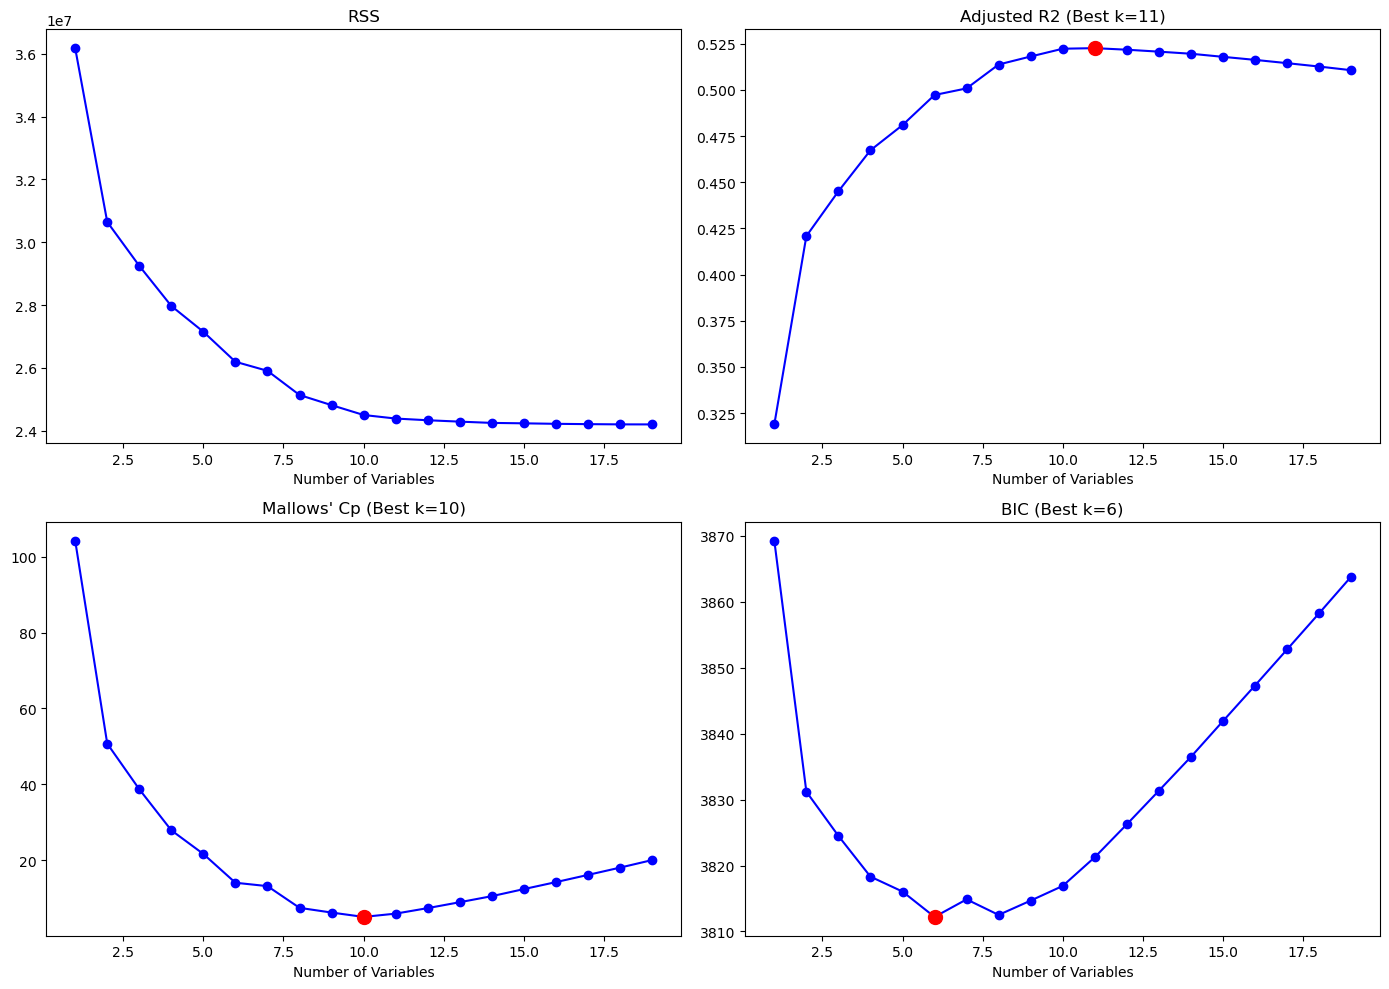

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. RSS
axes[0, 0].plot(df_summary["k"], df_summary["RSS"], marker="o", color="b")
axes[0, 0].set_title("RSS")
axes[0, 0].set_xlabel("Number of Variables")

# 2. Adjusted R2
axes[0, 1].plot(df_summary["k"], df_summary["Adj_R2"], marker="o", color="b")
axes[0, 1].scatter(best_adj_r2["k"], best_adj_r2["Adj_R2"], color="red", s=100, zorder=5)
axes[0, 1].set_title(f"Adjusted R2 (Best k={int(best_adj_r2['k'])})")
axes[0, 1].set_xlabel("Number of Variables")

# 3. Cp
axes[1, 0].plot(df_summary["k"], df_summary["Cp"], marker="o", color="b")
axes[1, 0].scatter(best_cp["k"], best_cp["Cp"], color="red", s=100, zorder=5)
axes[1, 0].set_title(f"Mallows' Cp (Best k={int(best_cp['k'])})")
axes[1, 0].set_xlabel("Number of Variables")

# 4. BIC
axes[1, 1].plot(df_summary["k"], df_summary["BIC"], marker="o", color="b")
axes[1, 1].scatter(best_bic["k"], best_bic["BIC"], color="red", s=100, zorder=5)
axes[1, 1].set_title(f"BIC (Best k={int(best_bic['k'])})")
axes[1, 1].set_xlabel("Number of Variables")

plt.tight_layout()
plt.show()

In [24]:
print("--- Coefficients best 6-variables model (BIC) ---")
best_6_model = best_models[6]["model"]
print(best_6_model.params)

--- Coefficients best 6-variables model (BIC) ---
AtBat          -1.868589
Hits            7.604398
Walks           3.697647
CRBI            0.643017
PutOuts         0.264308
Division_W   -122.951534
const          91.511798
dtype: float64


Based on computed and lotted information we can draw next conslusions:
- The more variables we add to the model the more $R^2$ we get and the less RSS
- The only one measure that should be maximum for choosing is adjusted $R^2$. Here we cann see that when k=11 then adjusted $R^2$ has maximum value
- The $C_p$ measure has chosen the model with 10 k. It means that the measure does not have big benalty for amount of features
- In contrast, the BIC meassure include $log$ penalty for using bug amount of features, therefore in this certain measure the best value was riached when k=6

#### Task 6.5.2 Forward and Backward Stepwise Selection

In [32]:
# --- FORWARD STEPWISE SELECTION ---
def forward_selection(X, y, nvmax=19):
    features_without_const = [col for col in X.columns if col != "const"]
    current_features = ["const"]
    models_forward = {}
    
    for k in range(1, nvmax + 1):
        remaining_features = [f for f in features_without_const if f not in current_features]
        best_rss = np.inf
        best_feature = None
        best_model = None

        # looking for one best feature on order to add
        for feature in remaining_features:
            test_features = current_features + [feature]
            model = sm.OLS(y, X[test_features]).fit()
            if model.ssr < best_rss:
                best_rss = model.ssr
                best_feature = feature
                best_model = model
                
        current_features.append(best_feature)
        models_forward[k] = {"model": best_model, "features": list(current_features)}
    return models_forward


# --- BACKWARD STEPWISE SELECTION ---
def backward_selection(X, y, nvmax=19):
    features_without_const = [col for col in X.columns if col != "const"]
    current_features = features_without_const + ["const"]
    models_backward = {}
    
    # start with the full model
    full_model = sm.OLS(y, X[current_features]).fit()
    models_backward[19] = {"model": full_model, "features": list(current_features)}
    
    for k in range(18, 0, -1):
        features_to_test = [f for f in current_features if f != "const"]
        best_rss = np.inf
        feature_to_remove = None
        best_model = None

        # looking for the worst model in order to get rid of it
        for feature in features_to_test:
            test_features = [f for f in current_features if f != feature]
            model = sm.OLS(y, X[test_features]).fit()
            if model.ssr < best_rss:
                best_rss = model.ssr
                feature_to_remove = feature
                best_model = model
                
        current_features.remove(feature_to_remove)
        models_backward[k] = {"model": best_model, "features": list(current_features)}
    return models_backward


models_fwd = forward_selection(X, y, nvmax=19)
models_bwd = backward_selection(X, y, nvmax=19)

print("--- Comparing the models k=7 ---")
print("\n[Forward Selection k=7]:")
print(models_fwd[7]['model'].params)

print("\n[Backward Selection k=7]:")
print(models_bwd[7]['model'].params)

print("\n[Best Subset Selection models k=7]")
best_7_model = best_models[7]["model"]
print(best_7_model.params)

--- Comparing the models k=7 ---

[Forward Selection k=7]:
const         109.787306
CRBI            0.853762
Hits            7.449877
PutOuts         0.253340
Division_W   -127.122393
AtBat          -1.958885
Walks           4.913140
CWalks         -0.305307
dtype: float64

[Backward Selection k=7]:
AtBat          -1.976284
Hits            6.757491
Walks           6.055869
CRuns           1.129309
CWalks         -0.716335
PutOuts         0.302885
Division_W   -116.169217
const         105.648749
dtype: float64

[Best Subset Selection models k=7]
Hits            1.283351
Walks           3.227426
CAtBat         -0.375235
CHits           1.495707
CHmRun          1.442054
PutOuts         0.236681
Division_W   -129.986643
const          79.450947
dtype: float64


As we can see all three approaches have chosen different features. The difference in methods is clearly seen

#### Task 6.5.3 Choosing Among Models Using the Validation Set Approach and Cross-Validation

We just saw that it is possible to choose among a set of models of different
sizes using Cp, BIC, and adjusted R2. We will now consider how to do this
using the validation set and cross-validation approaches.
In order for these approaches to yield accurate estimates of the test
error, we must use only the training observations to perform all aspects of
model-fitting—including variable selection. Therefore, the determination of
which model of a given size is best must be made using only the training
observations. This point is subtle but important. If the full data set is used
to perform the best subset selection step, the validation set errors and
cross-validation errors that we obtain will not be accurate estimates of the
test error.

In [33]:
from sklearn.metrics import mean_squared_error

In [34]:
X = sm.add_constant(hitters.drop(columns=["Salary"])).astype(float)
y = hitters["Salary"].astype(float)

In [37]:
np.random.seed(1)
train_mask = np.random.choice([True, False], size=len(hitters), p=[0.5, 0.5])

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[~train_mask], y[~train_mask]

features_list = [col for col in X.columns if col != "const"]

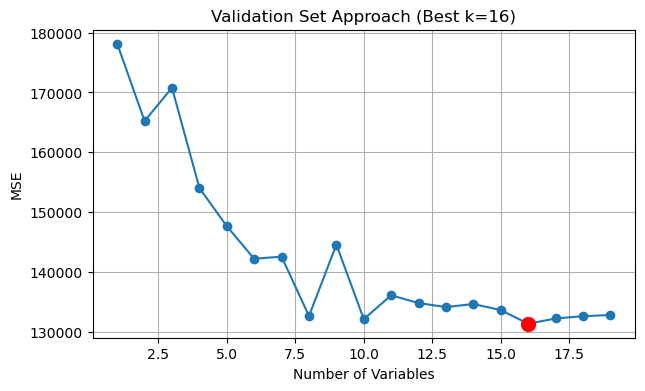

--- Best coefficient using full data set k=16 ---
AtBat          -1.970974
Hits            7.435772
HmRun           4.112045
Runs           -2.223676
RBI            -0.988085
Walks           6.171224
CAtBat         -0.189278
CHits           0.191540
CRuns           1.437738
CRBI            0.744465
CWalks         -0.803505
PutOuts         0.283100
Assists         0.378577
Errors         -3.230934
League_N       42.925267
Division_W   -115.845735
const         148.583625
dtype: float64


In [41]:
# the functions for searching the best model k size on train data
def get_best_subset_on_train(X_tr, y_tr, k):
    results = []
    for combo in itertools.combinations(features_list, k):
        combo_with_const = list(combo) + ["const"]
        model = sm.OLS(y_tr, X_tr[combo_with_const]).fit()
        results.append({"RSS": model.ssr, "features": combo_with_const})
    return pd.DataFrame(results).loc[pd.DataFrame(results)['RSS'].idxmin()]["features"]


val_errors = []
best_features_per_k = {}

for k in range(1, 20):

    best_features = get_best_subset_on_train(X_train, y_train, k)
    best_features_per_k[k] = best_features
    
    model_train = sm.OLS(y_train, X_train[best_features]).fit()
    
    preds = model_train.predict(X_val[best_features])
    val_errors.append(mean_squared_error(y_val, preds))

best_k_val = np.argmin(val_errors) + 1

plt.figure(figsize=(7, 4))
plt.plot(range(1, 20), val_errors, marker='o')
plt.scatter(best_k_val, val_errors[best_k_val-1], color='red', s=100, zorder=5)
plt.title(f"Validation Set Approach (Best k={best_k_val})")
plt.xlabel("Number of Variables")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

print(f"--- Best coefficient using full data set k={best_k_val} ---")
full_features = get_best_subset_on_train(X, y, best_k_val)
final_model_val = sm.OLS(y, X[full_features]).fit()
print(final_model_val.params)

In [42]:
from sklearn.model_selection import KFold

In [ ]:
kf = KFold(n_splits=10, shuffle=True, random_state=1)
cv_errors_matrix = np.zeros((10, 19))

fold_idx = 0
for train_idx, test_idx in kf.split(X):
    X_tr_fold, y_tr_fold = X.iloc[train_idx], y.iloc[train_idx]
    X_te_fold, y_te_fold = X.iloc[test_idx], y.iloc[test_idx]
    
    for k in range(1, 20):

        best_features = get_best_subset_on_train(X_tr_fold, y_tr_fold, k)
        
        model_fold = sm.OLS(y_tr_fold, X_tr_fold[best_features]).fit()
        
        preds_fold = model_fold.predict(X_te_fold[best_features])
        cv_errors_matrix[fold_idx, k-1] = mean_squared_error(y_te_fold, preds_fold)
        
    fold_idx += 1


mean_cv_errors = cv_errors_matrix.mean(axis=0)
best_k_cv = np.argmin(mean_cv_errors) + 1

plt.figure(figsize=(7, 4))
plt.plot(range(1, 20), mean_cv_errors, marker='o', color='purple')
plt.scatter(best_k_cv, mean_cv_errors[best_k_cv-1], color='red', s=100, zorder=5)
plt.title(f"10-Fold Cross-Validation (Best k={best_k_cv})")
plt.xlabel("Number of Variables")
plt.ylabel("Mean CV MSE")
plt.grid(True)
plt.show()

print(f"--- Best coefficient using full data set k={best_k_cv} ---")
full_features_cv = get_best_subset_on_train(X, y, best_k_cv)
final_model_cv = sm.OLS(y, X[full_features_cv]).fit()
print(final_model_cv.params)

Validation set approach has chosen k=16

#### Task 6.6.1 Ridge Regression

In [44]:
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler

In [46]:
hitters = pd.read_csv("data/Hitters.csv").dropna()
hitters = pd.get_dummies(hitters, columns=["League", "Division", "NewLeague"], drop_first=True, dtype=int)

X = hitters.drop(columns=["Salary"]).astype(float)
y = hitters["Salary"].astype(float)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

lambdas = 10**np.linspace(10, -2, 100)

coefs = []

for l in lambdas:
    ridge = Ridge(alpha=l)
    ridge.fit(X_scaled_df, y)
    coefs.append(ridge.coef_)

# check dimention of matrix
print(f"The dimention coefficients matrix: {np.array(coefs).shape}")

large_lambda = lambdas[40]
ridge_large = Ridge(alpha=large_lambda).fit(X_scaled_df, y)
l2_norm_large = np.sqrt(np.sum(ridge_large.coef_**2))

print(f"\nIn case large Lambda = {large_lambda:.2f}:")
print(f"L2 norm coefficients (without intercept): {l2_norm_large:.4f}")


small_lambda = lambdas[80]
ridge_small = Ridge(alpha=small_lambda).fit(X_scaled_df, y)
l2_norm_small = np.sqrt(np.sum(ridge_small.coef_**2))

print(f"\nIn case small Lambda = {small_lambda:.2f}:")
print(f"L2 norm coefficients (without intercept): {l2_norm_small:.4f}")

The dimention coefficients matrix: (100, 19)

In case large Lambda = 141747.42:
L2 norm coefficients (without intercept): 1.4428

In case small Lambda = 2.01:
L2 norm coefficients (without intercept): 557.5078


A large value of $\lambda$ leads to an increase in test MSE. When we restrict the model too heavily, the weights cannot reach their optimal values. The model fails to capture underlying patterns, which increases bias and leads to underfitting

In [51]:
# splitting test/train
np.random.seed(1)
train_indices = np.random.choice(X.index, size=len(X)//2, replace=False)
test_indices = X.index.difference(train_indices)

scaler_split = StandardScaler()
X_train_scaled = scaler_split.fit_transform(X.loc[train_indices])
X_test_scaled = scaler_split.transform(X.loc[test_indices])

y_train = y.loc[train_indices]
y_test = y.loc[test_indices]

# the estimating base scenario (lambda = 4)
ridge_lambda_4 = Ridge(alpha=4)
ridge_lambda_4.fit(X_train_scaled, y_train)
pred_4 = ridge_lambda_4.predict(X_test_scaled)
print(f"\nMSE Lambda=4: {mean_squared_error(y_test, pred_4):.2f}")

# 2. lambda is seeking to infinity
ridge_huge = Ridge(alpha=1e10)
ridge_huge.fit(X_train_scaled, y_train)
pred_huge = ridge_huge.predict(X_test_scaled)
print(f"MSE huge Lambda: {mean_squared_error(y_test, pred_huge):.2f}")

# 3. lambda = 0
ridge_zero = Ridge(alpha=0)
ridge_zero.fit(X_train_scaled, y_train)
pred_zero = ridge_zero.predict(X_test_scaled)
print(f"MSE при Lambda=0 (обычный OLS): {mean_squared_error(y_test, pred_zero):.2f}")

# 4. searching the balance
ridge_cv = RidgeCV(alphas=lambdas, cv=10, scoring="neg_mean_squared_error")
ridge_cv.fit(X_train_scaled, y_train)

best_lambda = ridge_cv.alpha_
print(f"\n[Result CV] The best Lambda 10-Fold CV: {best_lambda:.2f}")

# Computing test MSE
best_ridge = Ridge(alpha=best_lambda)
best_ridge.fit(X_train_scaled, y_train)
pred_best = best_ridge.predict(X_test_scaled)
print(f"The final test MSE with best Lambda: {mean_squared_error(y_test, pred_best):.2f}")

# 5. fit the full data set with best lambda
final_scaler = StandardScaler()
X_full_scaled = final_scaler.fit_transform(X)

final_ridge = Ridge(alpha=best_lambda)
final_ridge.fit(X_full_scaled, y)

print("\n--- Ridge coefficients on full data set ---")
for col, coef in zip(X.columns, final_ridge.coef_):
    print(f"{col}: {coef:.4f}")


MSE Lambda=4: 117707.48
MSE huge Lambda: 231330.85
MSE при Lambda=0 (обычный OLS): 118094.97

[Result CV] The best Lambda 10-Fold CV: 174.75
The final test MSE with best Lambda: 133596.13

--- Ridge coefficients on full data set ---
AtBat: 10.2986
Hits: 39.9225
HmRun: 4.5544
Runs: 27.4107
RBI: 22.7314
Walks: 35.9521
Years: 5.6090
CAtBat: 25.9458
CHits: 37.9840
CHmRun: 33.9506
CRuns: 38.6048
CRBI: 40.0333
CWalks: 13.0231
PutOuts: 47.8742
Assists: 4.5709
Errors: -9.5453
League_N: 11.5214
Division_W: -40.8138
NewLeague_N: 4.4378


The experiments results displayed next findigs:
- The big amoun of $\lambda$ leads to increasing in test MSE. Hence when we strongly limit the model, the weights cannot be increased to proper values. The model cannot catch the patterns and therefore increases bias. It may be the sign of underfitting
- A small amount of regularization ($\lambda = 4$) managed to outperform OLS. In this case, the model was slightly constrained, allowing it to find more robust weights and better generalize the patterns.
- The optimal value of $\lambda = 174.75$ was found via 10-fold cross-validation. This balance prevents both overfitting and underfitting by finding the sweet spot on the bias-variance tradeoff curve